![Python](https://img.shields.io/badge/python-3.9-blue)
![Status: Pending Migration](https://img.shields.io/badge/status-pending%20migration-orange)

<a id="table-of-contents"></a>
# 🧾 Embeddings & Similarity  
- [📄 Introduction](#introduction)  
- [🧱 Word Embedding Concepts](#embedding-concepts)  
- [🔤 Pretrained Embeddings (Word2Vec, GloVe)](#pretrained-embeddings)  
- [🧰 Loading and Using Embeddings](#loading-embeddings)  
- [📏 Similarity Measures](#similarity-measures)  
- [🧪 Use Cases: Search, Deduplication, Clustering](#use-cases)  
- [📈 Visualizing Embeddings](#visualization)  
- [🧪 Edge Cases & Practical Tips](#edge-cases)  
___

<a id="introduction"></a>  
# 📄 Introduction  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 📄 Introduction

In traditional NLP approaches like Bag-of-Words or TF-IDF, words are treated as independent entities without any notion of meaning or context. This limits their ability to capture relationships between words like *king* and *queen*, or *Paris* and *France*.

**Embeddings** solve this by representing words, sentences, or documents as dense vectors in a high-dimensional space. These vectors are learned from large corpora and encode semantic similarity: words with similar meanings are placed close together.

This notebook will walk through:

- **Word Embeddings**: How to convert individual words into vectors using models like Word2Vec, GloVe, and FastText.
- **Sentence Embeddings**: How to build vector representations of full sentences using techniques like averaging and Sentence-BERT (SBERT).
- **Similarity Metrics**: How to compare vectors using cosine similarity and Euclidean distance.
- **Practical Use Case**: Finding similar customer reviews using sentence embeddings and nearest neighbor search.
- **Visualization & Tips**: Understanding the geometry of embeddings and addressing edge cases.

We’ll use real-world review data (Amazon/Yelp/IMDB) for applied learning throughout.

</details>


[Back to the top](#table-of-contents)
___


<a id="embedding-concepts"></a>  
# 🧱 Word Embedding Concepts



#### 🔢 Dense vs Sparse Representations  
<a id="dense-vs-sparse"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🔢 Dense vs Sparse Representations

Traditional methods like **Bag-of-Words (BoW)** or **TF-IDF** create **sparse vectors** — large arrays filled mostly with zeros. These are high-dimensional (one dimension per word in the vocabulary) and do not capture relationships between words.

**Word Embeddings**, on the other hand, are **dense vectors** — compact arrays (typically 50–300 dimensions) where each element holds some semantic information. These dense representations are learned such that similar words have similar vectors.

**Example**:

| Word       | Sparse Vector (TF-IDF)           | Dense Vector (Embedding)     |
|------------|----------------------------------|-------------------------------|
| "king"     | [0, 0.5, 0, ..., 0]               | [0.12, -0.38, ..., 0.09]      |
| "queen"    | [0, 0.5, 0, ..., 0]               | [0.10, -0.35, ..., 0.11]      |

Dense embeddings are useful in deep learning models and similarity computations because they are compact and encode relationships between words.

</details>




In [1]:
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models import Word2Vec

# Sample corpus
corpus = [
    "The king rules the kingdom",
    "The queen is wise and strong",
    "The man is walking in the park",
    "She is a powerful woman"
]

# Sparse: TF-IDF
tfidf = TfidfVectorizer()
X_sparse = tfidf.fit_transform(corpus)

print("🔍 Sparse TF-IDF shape:", X_sparse.shape)

# Dense: Word2Vec
tokenized = [doc.lower().split() for doc in corpus]
w2v_model = Word2Vec(sentences=tokenized, vector_size=50, window=5, min_count=1, sg=1)

print("📏 Dense Embedding for 'king':")
print(w2v_model.wv['king'])


🔍 Sparse TF-IDF shape: (4, 16)
📏 Dense Embedding for 'king':
[ 1.56351421e-02 -1.90203730e-02 -4.11062239e-04  6.93839323e-03
 -1.87794445e-03  1.67635437e-02  1.80215668e-02  1.30730132e-02
 -1.42324204e-03  1.54208085e-02 -1.70686692e-02  6.41421322e-03
 -9.27599426e-03 -1.01779103e-02  7.17923651e-03  1.07406788e-02
  1.55390287e-02 -1.15330126e-02  1.48667218e-02  1.32509926e-02
 -7.41960062e-03 -1.74912829e-02  1.08749345e-02  1.30195115e-02
 -1.57510047e-03 -1.34197120e-02 -1.41718509e-02 -4.99412045e-03
  1.02865072e-02 -7.33047491e-03 -1.87401194e-02  7.65347946e-03
  9.76895820e-03 -1.28571270e-02  2.41711619e-03 -4.14975407e-03
  4.88066689e-05 -1.97670180e-02  5.38400887e-03 -9.50021297e-03
  2.17529293e-03 -3.15244915e-03  4.39334614e-03 -1.57631524e-02
 -5.43436781e-03  5.32639725e-03  1.06933638e-02 -4.78302967e-03
 -1.90201886e-02  9.01175756e-03]


#### 🧠 Semantic Properties of Embeddings  
<a id="embedding-properties"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧠 Semantic Properties of Embeddings

One of the most fascinating aspects of word embeddings is their ability to **encode meaning through geometry**.

For example:
- `vector("king") - vector("man") + vector("woman") ≈ vector("queen")`
- Similar words cluster together in space: `["happy", "joyful", "glad"]` are near each other.

These relationships emerge because embeddings are trained to **predict context**, which forces them to learn meaningful associations.

Word embeddings also support:
- **Synonym detection**
- **Analogy solving**
- **Clustering and classification**
- **Downstream transfer learning**

These semantic properties make embeddings powerful building blocks in modern NLP workflows.

</details>



In [2]:
# Check similarity
print("Similarity between 'king' and 'queen':", w2v_model.wv.similarity('king', 'queen'))
print("Similarity between 'man' and 'woman':", w2v_model.wv.similarity('man', 'woman'))

# Word analogies
result = w2v_model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=1)
print("👑 'King' - 'Man' + 'Woman' ≈", result)


Similarity between 'king' and 'queen': -0.044072118
Similarity between 'man' and 'woman': 0.23735215
👑 'King' - 'Man' + 'Woman' ≈ [('in', 0.18500587344169617)]


[Back to the top](#table-of-contents)
___


<a id="pretrained-embeddings"></a>  
# 🔤 Pretrained Embeddings (Word2Vec, GloVe)



#### 🧠 Word2Vec: CBOW & Skip-Gram  
<a id="word2vec"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

**Word2Vec** is a family of algorithms that learns word embeddings by predicting context:

- **CBOW (Continuous Bag-of-Words)**: Predicts the target word given surrounding context words.
- **Skip-Gram**: Predicts the context words given a target word.

Trained on large corpora, Word2Vec learns to position semantically similar words near each other in the embedding space.

Key properties:
- Trained locally on **context windows**
- Captures **syntactic and semantic** patterns
- Fast and scalable (negative sampling, hierarchical softmax)

Example relationship:
vector("king") - vector("man") + vector("woman") ≈ vector("queen")

You can use pretrained Word2Vec models via `gensim.downloader`.
</details>




In [3]:
import gensim.downloader as api

# This may take a few minutes the first time
print("⏳ Downloading Word2Vec model...")
w2v_model = api.load("word2vec-google-news-300")

print("✅ Model loaded!")
print("Vector for 'pizza':", w2v_model['pizza'][:10])
print("Similarity between 'pizza' and 'burger':", w2v_model.similarity('pizza', 'burger'))

# Analogy
print("Analogy: king - man + woman ≈", w2v_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=1))


⏳ Downloading Word2Vec model...
[==================================================] 100.0% 1662.8/1662.8MB downloaded
✅ Model loaded!
Vector for 'pizza': [-1.2597656e-01  2.5390625e-02  1.6699219e-01  5.5078125e-01
 -7.6660156e-02  1.2890625e-01  1.0253906e-01 -3.9482117e-04
  1.2158203e-01  4.3212891e-02]
Similarity between 'pizza' and 'burger': 0.65696925
Analogy: king - man + woman ≈ [('queen', 0.7118192911148071)]


#### 📘 GloVe: Global Co-occurrence  
<a id="glove"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 📘 GloVe: Global Co-occurrence

**GloVe (Global Vectors for Word Representation)** is another popular embedding technique, developed by Stanford.

Unlike Word2Vec (which learns from local windows), GloVe uses a **co-occurrence matrix** across the entire corpus, capturing **global statistics**.

Training Objective:
- Minimizes the difference between the dot product of word vectors and the log of their co-occurrence count.

Advantages:
- Captures both **semantic** and **subtle global relationships**
- Pretrained embeddings available in many dimensions (50D, 100D, 300D, etc.)

Example:  
vector("Paris") - vector("France") + vector("Italy") ≈ vector("Rome")
</details>



In [4]:
# Use gensim to load GloVe via API
print("⏳ Loading GloVe vectors...")
glove_model = api.load("glove-wiki-gigaword-100")

print("✅ GloVe loaded!")
print("Vector for 'amazon':", glove_model['amazon'][:10])
print("Similarity between 'strong' and 'powerful':", glove_model.similarity('strong', 'powerful'))

# Analogy
print("Analogy: Paris - France + Italy ≈", glove_model.most_similar(positive=['paris', 'italy'], negative=['france'], topn=1))


⏳ Loading GloVe vectors...
[==================================================] 100.0% 128.1/128.1MB downloaded
✅ GloVe loaded!
Vector for 'amazon': [-0.17584  -0.43957   1.1987    0.19586   0.98309  -0.13039  -0.17482
  0.024014  0.22434  -0.20326 ]
Similarity between 'strong' and 'powerful': 0.6897354
Analogy: Paris - France + Italy ≈ [('rome', 0.8189547061920166)]


[Back to the top](#table-of-contents)
___


<a id="loading-embeddings"></a>  
# 🧰 Loading and Using Embeddings



#### 🧳 Load Pretrained Models (Gensim / TextVectors)  
<a id="load-pretrained"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧳 Grab-and-Go Embeddings for Real-World NLP

Instead of training embeddings from scratch, we often load **pretrained word vectors**. These are trained on massive corpora (Wikipedia, Google News, Common Crawl) and capture rich semantics out-of-the-box.

Popular sources:
- `gensim.downloader`: Quick access to Word2Vec, GloVe, FastText
- HuggingFace / Spacy / torchtext for model-based embeddings (e.g. BERT, SBERT)

Once loaded, these vectors can:
- Be used to initialize neural networks
- Power document similarity engines
- Perform clustering, classification, and search

</details>




In [5]:
import gensim.downloader as api

# List available pretrained embeddings
print("🧾 Available pretrained embeddings:")
print(api.info().keys())

# Load a small one for speed during experimentation
glove_small = api.load("glove-wiki-gigaword-50")
print("✅ Sample vector for 'computer':", glove_small['computer'][:10])


🧾 Available pretrained embeddings:
dict_keys(['corpora', 'models'])
[==================================================] 100.0% 66.0/66.0MB downloaded
✅ Sample vector for 'computer': [ 0.079084 -0.81504   1.7901    0.91653   0.10797  -0.55628  -0.84427
 -1.4951    0.13418   0.63627 ]


#### 🧾 Generate Document Embeddings (Averaging, TF-IDF Weighted)  
<a id="doc-embeddings"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧾 From Words to Whole Thoughts: Document-Level Vectors

Word embeddings are for single tokens — but we often need vectors for entire **sentences** or **documents**.

Two simple methods:
- **Averaging**: Take the mean of all word vectors in a document.
- **TF-IDF Weighted Average**: Weigh important words more heavily before averaging.

These techniques work surprisingly well for:
- Text classification
- Clustering
- Similarity search

More advanced alternatives include **sentence transformers**, but these simple baselines are fast and effective.

</details>


In [6]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample corpus
docs = [
    "The phone has great battery life",
    "This laptop is lightweight and powerful",
    "Amazing camera with sharp images",
    "Battery dies quickly and performance is poor"
]

# Load pretrained word vectors
w2v = api.load("glove-wiki-gigaword-50")

# Tokenize and filter out OOV
def get_avg_vector(text):
    tokens = text.lower().split()
    vectors = [w2v[word] for word in tokens if word in w2v]
    return np.mean(vectors, axis=0) if vectors else np.zeros(w2v.vector_size)

# Average Embedding
doc_embeddings = np.vstack([get_avg_vector(doc) for doc in docs])
print("📐 Document embeddings shape (avg):", doc_embeddings.shape)

# TF-IDF Weighted Embedding
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(docs)
tfidf_vocab = tfidf.vocabulary_

def get_weighted_vector(doc):
    words = doc.lower().split()
    word_scores = [tfidf.idf_[tfidf_vocab[word]] * w2v[word] 
                   for word in words if word in tfidf_vocab and word in w2v]
    return np.mean(word_scores, axis=0) if word_scores else np.zeros(w2v.vector_size)

weighted_embeddings = np.vstack([get_weighted_vector(doc) for doc in docs])
print("🧮 Document embeddings shape (TF-IDF):", weighted_embeddings.shape)


📐 Document embeddings shape (avg): (4, 50)
🧮 Document embeddings shape (TF-IDF): (4, 50)


[Back to the top](#table-of-contents)
___


<a id="similarity-measures"></a>  
# 📏 Similarity Measures



#### 🧭 Cosine Similarity  
<a id="cosine-similarity"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧭 Navigating Vector Space with Cosine Similarity

Cosine similarity measures **how aligned two vectors are**, regardless of their magnitude. It’s defined as:

cosine_similarity(a, b) = (a · b) / (||a|| * ||b||)

Why it works well in NLP:
- Text vectors often differ in length (word count, sentence length)
- Cosine focuses on **direction**, not scale
- Values range from **-1 to 1**, where:
  - 1 = same direction (very similar)
  - 0 = orthogonal (unrelated)
  - -1 = opposite meaning (rare in text)

This is the go-to metric for text similarity and semantic search.

</details>




In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Using doc_embeddings from earlier section (averaged vectors)
cos_sim_matrix = cosine_similarity(doc_embeddings)

# Show as labeled DataFrame
similarity_df = pd.DataFrame(cos_sim_matrix, columns=[f"Doc {i+1}" for i in range(len(docs))],
                             index=[f"Doc {i+1}" for i in range(len(docs))])
print("🧭 Cosine Similarity Matrix:")
display(similarity_df.round(2))


🧭 Cosine Similarity Matrix:


,Doc 1,Doc 2,Doc 3,Doc 4
Doc 1,1.00,0.92,0.80,0.94
Doc 2,0.92,1.00,0.81,0.90
Doc 3,0.80,0.81,1.00,0.79
Doc 4,0.94,0.90,0.79,1.00


#### 📉 Euclidean & Other Distances  
<a id="other-similarity"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 📉 Measuring Literal Distance in Vector Space

While cosine similarity measures **angle**, Euclidean distance measures **actual distance** in space:

euclidean(a, b) = sqrt(Σ (aᵢ - bᵢ)²)

Other common metrics:
- **Manhattan (L1)**: Absolute differences
- **Chebyshev**: Max coordinate difference
- **Minkowski**: Generalized form (p=1 → L1, p=2 → L2)

When to use which?
- **Cosine**: For semantic similarity (text, embeddings)
- **Euclidean**: For clustering, spatial interpretation
- **Others**: In special distance-aware models or nearest neighbor tasks

</details>



In [8]:
from sklearn.metrics.pairwise import euclidean_distances

euclid_matrix = euclidean_distances(doc_embeddings)

# Show as labeled DataFrame
euclid_df = pd.DataFrame(euclid_matrix, columns=[f"Doc {i+1}" for i in range(len(docs))],
                         index=[f"Doc {i+1}" for i in range(len(docs))])
print("📉 Euclidean Distance Matrix:")
display(euclid_df.round(2))


📉 Euclidean Distance Matrix:


,Doc 1,Doc 2,Doc 3,Doc 4
Doc 1,0.00,1.56,2.44,1.35
Doc 2,1.56,0.00,2.34,1.62
Doc 3,2.44,2.34,0.00,2.39
Doc 4,1.35,1.62,2.39,0.00


[Back to the top](#table-of-contents)
___


<a id="use-cases"></a>  
# 🧪 Use Cases: Search, Deduplication, Clustering



#### 🔍 Semantic Search with Embedding Similarity  
<a id="semantic-search"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🔍 Vector Search that Actually Understands Meaning

Traditional keyword search breaks down when the query and documents use different words for the same idea (e.g. *"cheap"* vs *"affordable"*). Semantic search fixes this using **sentence embeddings**.

By encoding queries and documents into vectors using models like **SBERT**, we can use **cosine similarity** to find the most relevant matches — even if there’s no exact overlap in words.

Common use cases:
- FAQ retrieval
- Legal/medical document search
- Resume-to-job matching
- Product recommendation

</details>




In [11]:
from sentence_transformers import SentenceTransformer, util

# Sample corpus of customer reviews
corpus = [
    "This phone has amazing battery life.",
    "The battery dies quickly and is disappointing.",
    "Excellent camera and fast processor.",
    "Great performance and build quality.",
    "Terrible camera, very blurry pictures."
]

# Search query
query = "Which one has the best camera?"

# Load pretrained sentence transformer
model = SentenceTransformer('all-MiniLM-L6-v2')

# Encode corpus and query
corpus_embeddings = model.encode(corpus, convert_to_tensor=True)
query_embedding = model.encode(query, convert_to_tensor=True)

# Compute cosine similarity
cos_scores = util.pytorch_cos_sim(query_embedding, corpus_embeddings)[0]

# Sort results
top_results = cos_scores.argsort(descending=True)

print("🔎 Top semantic matches:\n")
for idx in top_results[:3]:
    print(f"Score: {cos_scores[idx]:.4f} | Text: {corpus[idx]}")


/Users/ashrithreddy/.pyenv/versions/3.10.13/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


🔎 Top semantic matches:

Score: 0.5719 | Text: Excellent camera and fast processor.
Score: 0.5371 | Text: Terrible camera, very blurry pictures.
Score: 0.2889 | Text: This phone has amazing battery life.


#### 🧾 Duplicate Text Detection  
<a id="deduplication"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧾 Find Duplicates That Aren’t Word-for-Word

Detecting duplicates is tricky when text has been paraphrased:
- *"The service was great."*
- *"They offered amazing service."*

Both mean the same, but traditional matching won’t catch it.

Using **sentence embeddings**, we can compute **pairwise cosine similarity** between all texts. If similarity exceeds a threshold (e.g., 0.9), the pair is flagged as a potential duplicate.

This technique is used in:
- Cleaning scraped datasets
- De-duplicating customer feedback
- Identifying repeated complaints or praise

</details>


In [12]:
import numpy as np
from itertools import combinations

# Slightly paraphrased duplicates
texts = [
    "Service was fast and professional.",
    "Very quick and polite service.",
    "The food was delicious.",
    "I loved the meal.",
    "The food was great.",
    "Terrible service, very rude staff."
]

# Encode
embeddings = model.encode(texts, convert_to_tensor=True)
scores = util.pytorch_cos_sim(embeddings, embeddings).cpu().numpy()

# Threshold for similarity
threshold = 0.85
print("🧾 Possible duplicates:\n")
for i, j in combinations(range(len(texts)), 2):
    if scores[i, j] >= threshold:
        print(f"{i}-{j} | Score: {scores[i, j]:.3f}")
        print(f"  ↪ \"{texts[i]}\"")
        print(f"  ↪ \"{texts[j]}\"\n")


🧾 Possible duplicates:

2-4 | Score: 0.856
  ↪ "The food was delicious."
  ↪ "The food was great."



#### 🧩 KMeans / Agglomerative Clustering  
<a id="embedding-clustering"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧩 Grouping Similar Thoughts: Clustering with Embeddings

Embedding vectors preserve semantic closeness — which makes them ideal for **clustering**.

Using algorithms like:
- **KMeans** (centroid-based, fast)
- **Agglomerative** (hierarchical, interpretable)

...we can group text snippets into themes:
- Customer pain points
- Product feature mentions
- Intent segmentation in chat logs

Each cluster holds texts that are semantically similar, even if they use different words.

</details>



huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


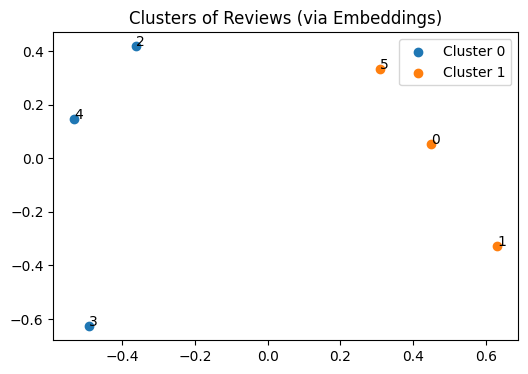

In [13]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Encode review snippets
docs = [
    "I love the camera quality.",
    "The pictures are very sharp and colorful.",
    "Battery life is terrible.",
    "It dies after just a few hours.",
    "Battery lasts long and charges fast.",
    "Camera is very poor in low light."
]

X = model.encode(docs)

# KMeans clustering
kmeans = KMeans(n_clusters=2, random_state=42)
labels = kmeans.fit_predict(X)

# Optional: visualize via PCA
pca = PCA(n_components=2)
X_2D = pca.fit_transform(X)

plt.figure(figsize=(6,4))
for label in set(labels):
    plt.scatter(X_2D[labels==label, 0], X_2D[labels==label, 1], label=f'Cluster {label}')
for i, txt in enumerate(docs):
    plt.annotate(i, (X_2D[i, 0], X_2D[i, 1]))
plt.title("Clusters of Reviews (via Embeddings)")
plt.legend()
plt.show()


[Back to the top](#table-of-contents)
___


<a id="visualization"></a>  
# 📈 Visualizing Embeddings

#### 🧮 t-SNE / PCA  
<a id="tsne-pca"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🧮 Shrinking the Universe: Projecting High-D Vectors

Word and sentence embeddings live in **high-dimensional space** (e.g., 300D). To visualize them, we need to compress them into 2D or 3D while preserving structure.

Two common techniques:
- **PCA (Principal Component Analysis)**: Fast, linear projection
- **t-SNE (t-distributed Stochastic Neighbor Embedding)**: Non-linear, preserves local structure

Use cases:
- Visualizing vocabulary relationships
- Spotting topic clusters
- Understanding separation between classes

</details>


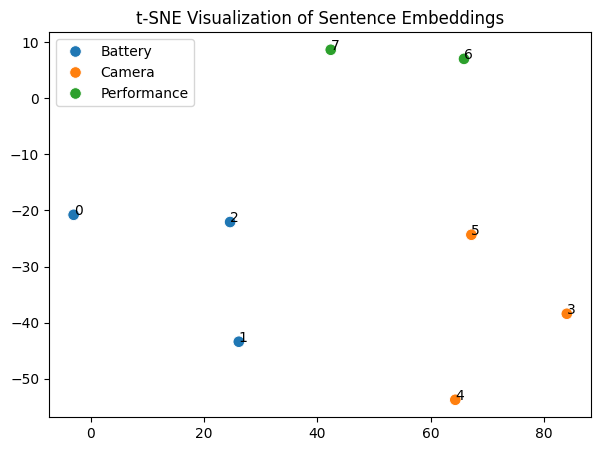

In [16]:
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Mini-corpus across different topics
sentences = [
    "The battery lasts all day.",
    "Charges very quickly.",
    "Horrible battery life, dies fast.",
    "Camera quality is incredible.",
    "Takes great photos in low light.",
    "Very blurry and grainy camera.",
    "Fast performance and smooth UI.",
    "Laggy interface and constant crashes."
]

labels = [
    "Battery", "Battery", "Battery",
    "Camera", "Camera", "Camera",
    "Performance", "Performance"
]

# Encode
X = model.encode(sentences)

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
X_tsne = tsne.fit_transform(X)

# Plot
plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=labels, palette="tab10", s=70)
for i, txt in enumerate(sentences):
    plt.annotate(str(i), (X_tsne[i, 0], X_tsne[i, 1]))
plt.title("t-SNE Visualization of Sentence Embeddings")
plt.legend()
plt.show()


#### 🖼️ 2D Plots for Topic Insights  
<a id="2d-embedding-plot"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 🖼️ Embeddings as Visual Topic Maps

When embeddings are projected into 2D space, you can start to **see themes form** — even without explicit topic modeling.

Examples:
- Positive vs Negative reviews cluster apart
- Camera-related comments form a distinct blob
- Duplicate or near-duplicate phrases overlap

This is useful for:
- Manual review of clusters
- Explaining similarity to stakeholders
- Debugging model behavior

</details>


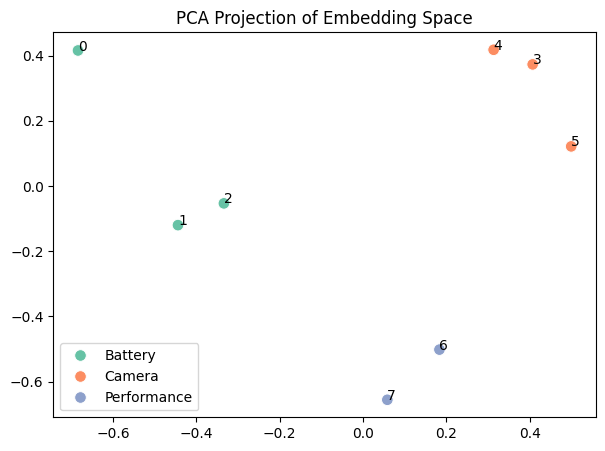

In [17]:
# Let’s do PCA for faster, more linear visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(7, 5))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels, palette="Set2", s=70)
for i, txt in enumerate(sentences):
    plt.annotate(str(i), (X_pca[i, 0], X_pca[i, 1]))
plt.title("PCA Projection of Embedding Space")
plt.legend()
plt.show()


[Back to the top](#table-of-contents)
___


<a id="edge-cases"></a>  
# 🧪 Edge Cases & Practical Tips



#### 📉 OOV Words & Coverage Issues  
<a id="oov-words"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### 📉 When the Model Hasn’t Seen Your Words

**Out-of-Vocabulary (OOV)** words are tokens not present in the embedding model's vocabulary.

This can happen when:
- The corpus has domain-specific terms (e.g. "polyphenols")
- Typos or slang are common (e.g. "amazzzing")
- You're using static models (Word2Vec/GloVe), not subword-aware models

OOVs are either:
- Skipped silently (leading to missing vectors)
- Replaced with zeros or average vectors

**Tips:**
- Use **FastText** or **Byte-Pair Encoding** models for subword coverage
- Preprocess text carefully (lowercase, spelling correction)
- Log missing tok




In [18]:
# Check coverage of a sample sentence
sample = "The camera is amazzzing but battery is meh"
tokens = sample.lower().split()

missing = [word for word in tokens if word not in glove_model]
print("📉 OOV Words (GloVe):", missing)


📉 OOV Words (GloVe): ['amazzzing']


#### ⚙️ Dimensionality Tradeoffs  
<a id="dimension-tradeoffs"></a>  

<details><summary><strong>📖 Click to Expand</strong></summary>

##### ⚙️ More Dimensions ≠ More Insight

Embeddings come in various sizes:
- Word2Vec: 100D, 300D
- GloVe: 50D, 100D, 300D
- FastText/BERT: 300D–1024D

**Higher dimensions**:
- Capture richer relationships
- Improve performance on large datasets

**Lower dimensions**:
- Train faster, store less
- Less risk of overfitting in small data

The best dimensionality depends on:
- Task complexity
- Model capacity
- Data availability

Use dimensionality reduction (PCA, UMAP) for analysis — but keep full vectors for modeling.

</details>


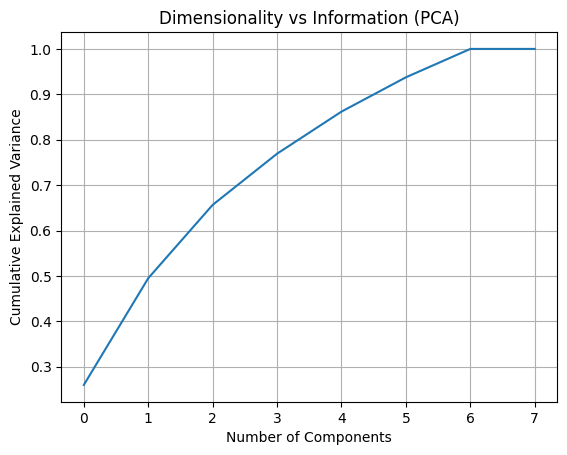

In [20]:
# Visual: how variance is captured as dimensions increase
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Run PCA on high-dim sentence embeddings
X_full = model.encode(sentences)
pca = PCA().fit(X_full)

# Plot explained variance
plt.plot(np.cumsum(pca.explained_variance_ratio_)[:50])
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Dimensionality vs Information (PCA)")
plt.grid(True)
plt.show()


[Back to the top](#table-of-contents)
___
